In [17]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
archivo_caidas = Path("C:\\Users\\PC\\Documents\\GitHub\\Proyecto-microprocesadores1\\Documentos\\Datos\\datos_capturados_caidas.csv")
archivo_normales = Path("C:\\Users\\PC\\Documents\\GitHub\\Proyecto-microprocesadores1\\Documentos\\Datos\\datos_capturados_normales.csv")

ARCHIVOS = {
    archivo_caidas: 1,      # caída
    archivo_normales: 0     # normal
}


In [19]:
COLUMNAS = [
    'cadera_ax','cadera_ay','cadera_az',
    'cadera_gx','cadera_gy','cadera_gz',
]
df_caidas = pd.read_csv(archivo_caidas)
df_normales = pd.read_csv(archivo_normales)

print(df_caidas.columns)
print(df_normales.columns)

Index(['cadera_ax', 'cadera_ay', 'cadera_az', 'cadera_gx', 'cadera_gy',
       'cadera_gz', 'pierna_ax', 'pierna_ay', 'pierna_az', 'pierna_gx',
       'pierna_gy', 'pierna_gz'],
      dtype='object')
Index(['cadera_ax', 'cadera_ay', 'cadera_az', 'cadera_gx', 'cadera_gy',
       'cadera_gz', 'pierna_ax', 'pierna_ay', 'pierna_az', 'pierna_gx',
       'pierna_gy', 'pierna_gz'],
      dtype='object')


In [20]:
WINDOW_SIZE = 40
OVERLAP = 20

datos_totales = []
etiquetas_totales = []

for archivo, etiqueta in ARCHIVOS.items():
    print("Procesando:", archivo.name)

    df = pd.read_csv(archivo)

    df = df[COLUMNAS].dropna()

    for i in range(0, len(df) - WINDOW_SIZE + 1, OVERLAP):
        ventana = df.iloc[i:i+WINDOW_SIZE].values
        datos_totales.append(ventana)
        etiquetas_totales.append(etiqueta)

X = np.array(datos_totales)
y = np.array(etiquetas_totales)

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Procesando: datos_capturados_caidas.csv
Procesando: datos_capturados_normales.csv
Forma de X: (9074, 40, 6)
Forma de y: (9074,)


In [21]:
num_muestras, pasos, num_features = X.shape

X_2d = X.reshape(-1, num_features)

scaler = StandardScaler()
X_2d = scaler.fit_transform(X_2d)

X = X_2d.reshape(num_muestras, pasos, num_features)

print(X.shape)

(9074, 40, 6)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(7259, 40, 6)
(1815, 40, 6)


In [23]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, num_features)),
    Dropout(0.3),

    LSTM(32),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 40, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 40, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,681 (123.75 KB)

 Trainable params: 31,681 (123.75 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9403 - loss: 0.1767 - val_accuracy: 0.9758 - val_loss: 0.0647
Epoch 2/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9766 - loss: 0.0768 - val_accuracy: 0.9708 - val_loss: 0.0734
Epoch 3/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9804 - loss: 0.0589 - val_accuracy: 0.9802 - val_loss: 0.0558
Epoch 4/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9832 - loss: 0.0544 - val_accuracy: 0.9675 - val_loss: 0.0926
Epoch 5/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9811 - loss: 0.0561 - val_accuracy: 0.9697 - val_loss: 0.0883
Epoch 6/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9846 - loss: 0.0507 - val_accuracy: 0.9802 - val_loss: 0.0568
Epoch 7/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9873 - loss: 0.0392 - val_accuracy: 0.9807 - val_loss: 0.0547
Epoch 8/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9879 - loss: 0.0333 - val_accu

In [25]:
loss, acc = model.evaluate(X_test, y_test)

print("Pérdida:", loss)
print("Precisión:", acc)

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9868 - loss: 0.0420
Pérdida: 0.04196251183748245
Precisión: 0.9867768883705139


In [26]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

print(classification_report(
    y_test,
    y_pred,
    target_names=['Normal', 'Caída']
))

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99       944
       Caída       0.99      0.98      0.99       871

    accuracy                           0.99      1815
   macro avg       0.99      0.99      0.99      1815
weighted avg       0.99      0.99      0.99      1815



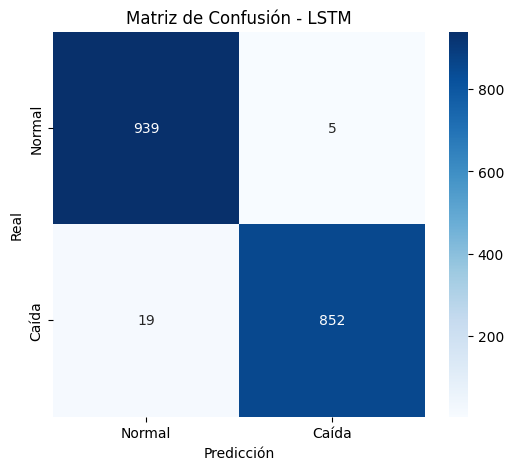

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Caída'],
    yticklabels=['Normal', 'Caída']
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - LSTM")
plt.show()

In [28]:
model.save("modelo_lstm_caidas.h5")
print("Modelo guardado correctamente")

Modelo guardado correctamente


In [30]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

with open("modelo_caidas.tflite", "wb") as f:
    f.write(tflite_model)

print("Modelo TFLite guardado correctamente")

INFO:tensorflow:Assets written to: C:\Users\PC\AppData\Local\Temp\tmpuunjmls9\assets


INFO:tensorflow:Assets written to: C:\Users\PC\AppData\Local\Temp\tmpuunjmls9\assets


Saved artifact at 'C:\Users\PC\AppData\Local\Temp\tmpuunjmls9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 40, 6), dtype=tf.float32, name='keras_tensor_8')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2789900563856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789900564048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789900565584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789900564624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789900565008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789900564816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789900566352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789900565968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789900565200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789900562512: TensorSpec(shape=(), dtype=tf.resource, name=None)
Modelo TFLite 